# Super Store Sales - Hypothesis Testing (Statistics With R)

### 1. Create the data (30 observations)

In [1]:
set.seed(123)
n <- 30

data <- data.frame(
  Obs          = 1:30,
  Age          = sample(16:81, n, replace = TRUE),
  Sales_Before = sample(10:95, n, replace = TRUE),
  Sales_After  = sample(10:117, n, replace = TRUE),
  Gender       = sample(c(rep(0, 14), rep(1, 16))),      # 0 = Female, 1 = Male
  Profession   = sample(c(rep(0, 15), rep(1, 15)))       # 0 = Executive, 1 = Manager
)

head(data, 10)

,Obs,Age,Sales_Before,Sales_After,Gender,Profession
,<int>,<int>,<int>,<int>,<dbl>,<dbl>
1,1,46,78,34,0,1
2,2,66,81,96,1,1
3,3,29,85,44,1,0
4,4,57,72,49,1,1
5,5,65,22,39,0,1
6,6,58,91,21,0,0
7,7,29,34,40,1,1
8,8,40,47,39,1,0
9,9,72,30,73,1,1


### 2. Hypotheses
Manager believes the mean age of customers is 40 years.

- **Ho:** mean age = 40
- **Ha:** mean age != 40 (two-tailed test)

Since the population SD is unknown and the sample is small (n = 30), a **one-sample t-test** is used.

### 3. Level of significance

In [2]:
alpha <- 0.05
mu0 <- 40

### 4. Sample statistics and t-statistic

In [3]:
x_bar <- mean(data$Age)
s     <- sd(data$Age)
se    <- s / sqrt(n)
df    <- n - 1

t_stat <- (x_bar - mu0) / se

cat("Sample mean    :", round(x_bar, 2), "\n")
cat("Sample SD      :", round(s, 2), "\n")
cat("Standard error :", round(se, 2), "\n")
cat("Degrees of freedom:", df, "\n")
cat("t-statistic    :", round(t_stat, 3), "\n")

Sample mean    : 45.83 
Sample SD      : 16.74 
Standard error : 3.06 
Degrees of freedom: 29 
t-statistic    : 1.908 


### 5. Critical value

In [4]:
t_critical <- qt(1 - alpha / 2, df)
cat("t_critical (+/-):", round(t_critical, 3), "\n")

t_critical (+/-): 2.045 


### 6. t-test using R function

In [5]:
result <- t.test(data$Age, mu = mu0, alternative = "two.sided", conf.level = 0.95)
result


	One Sample t-test

data:  data$Age
t = 1.9082, df = 29, p-value = 0.06631
alternative hypothesis: true mean is not equal to 40
95 percent confidence interval:
 39.58114 52.08552
sample estimates:
mean of x 
 45.83333 


### 7. Decision

In [6]:
cat("t-statistic :", round(t_stat, 3), "\n")
cat("t-critical  : +/-", round(t_critical, 3), "\n")
cat("p-value     :", round(result$p.value, 4), "\n\n")

if (abs(t_stat) > t_critical) {
  cat("Reject Ho: mean age is significantly different from 40 years.\n")
} else {
  cat("Fail to reject Ho: no evidence that mean age is different from 40 years.\n")
}

t-statistic : 1.908 
t-critical  : +/- 2.045 
p-value     : 0.0663 

Fail to reject Ho: no evidence that mean age is different from 40 years.


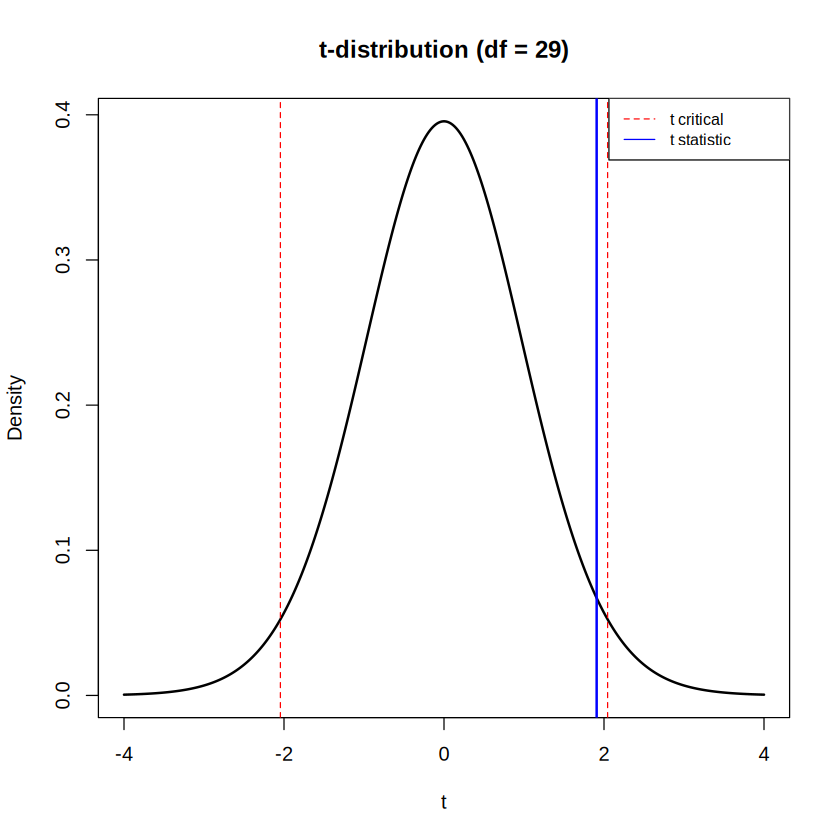

In [7]:
# Plot: rejection regions
xs <- seq(-4, 4, length.out = 400)
plot(xs, dt(xs, df), type = "l", lwd = 2, xlab = "t", ylab = "Density",
     main = "t-distribution (df = 29)")
abline(v = c(-t_critical, t_critical), col = "red", lty = 2)
abline(v = t_stat, col = "blue", lwd = 2)
legend("topright", legend = c("t critical", "t statistic"),
       col = c("red", "blue"), lty = c(2, 1), cex = 0.8)

### 8. Explanation of output
- **t-statistic:** how many standard errors the sample mean is away from 40.
- **df:** n - 1 = 29.
- **p-value:** probability of getting a sample mean this far from 40 if Ho is true. If p-value < 0.05, reject Ho.
- **95% confidence interval:** range of likely values for the true mean age. If 40 lies inside it, Ho is not rejected.
- **t_critical:** cut-off value for alpha = 0.05 (two-tailed). If |t-statistic| > t_critical, reject Ho.

### 9. Conclusion
- If |t-statistic| > t_critical (or p-value < 0.05): reject Ho, so the Manager's belief that the mean age is 40 is not supported by the data.
- Otherwise: fail to reject Ho, so the data does not contradict the Manager's belief.
- This is only a pilot study with 30 data points, so the result should be confirmed with the full survey of 2000 customers.